# personal-cgm-lab — Daily glucose SARIMAX model

Goal 4 from the capstone: build a daily forecasting model that answers *"what combination of walk minutes, carb load, and intermittent fasting moves my 7-day mean glucose toward an A1C of 6.0 (GMI ≈ 125 mg/dL)?"*

**Setup:**
- Target: `mean_glucose` (physiological-day mean, 4 AM boundary)
- Exogenous regressors: `total_walk_min`, `total_carbs`, `is_if_day`
  - `doses_taken` dropped — zero variance across all 84 days in this dataset
- Train/test split: last 21 days held out (same as per-meal model)
- Model family: SARIMAX with weekly seasonality (s=7), order selected by AIC grid
- Counterfactuals: project 30 days under three behavior scenarios

## 1. Setup & load

In [1]:
import os, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR  = os.path.abspath(os.path.join("..", "data", "processed"))
MODEL_DIR = os.path.abspath(os.path.join("..", "models"))
os.makedirs(MODEL_DIR, exist_ok=True)

daily = pd.read_csv(os.path.join(DATA_DIR, "daily_features.csv"), parse_dates=["date"])
daily = daily.sort_values("date").reset_index(drop=True)

print(f"Loaded {len(daily)} days  ({daily['date'].min().date()} -> {daily['date'].max().date()})")
print(f"Mean glucose:   {daily['mean_glucose'].mean():.1f} mg/dL")
print(f"A1C 6.0 target: ~125 mg/dL   Gap: {daily['mean_glucose'].mean() - 125:.1f} mg/dL")

EXOG_COLS = ["total_walk_min", "total_carbs", "is_if_day"]
print(f"\nExog variable summary:")
print(daily[EXOG_COLS].describe().round(1))
print(f"\nZero-walk days: {(daily['total_walk_min']==0).sum()} / {len(daily)}")

Loaded 84 days  (2026-02-01 -> 2026-04-28)
Mean glucose:   175.0 mg/dL
A1C 6.0 target: ~125 mg/dL   Gap: 50.0 mg/dL

Exog variable summary:
       total_walk_min  total_carbs  is_if_day
count            84.0         84.0       84.0
mean             16.7        113.0        0.2
std              17.1         51.7        0.4
min               0.0         24.0        0.0
25%               0.0         71.2        0.0
50%              22.0        111.0        0.0
75%              28.0        143.0        0.0
max              67.0        305.0        1.0

Zero-walk days: 39 / 84


## 2. Target series overview

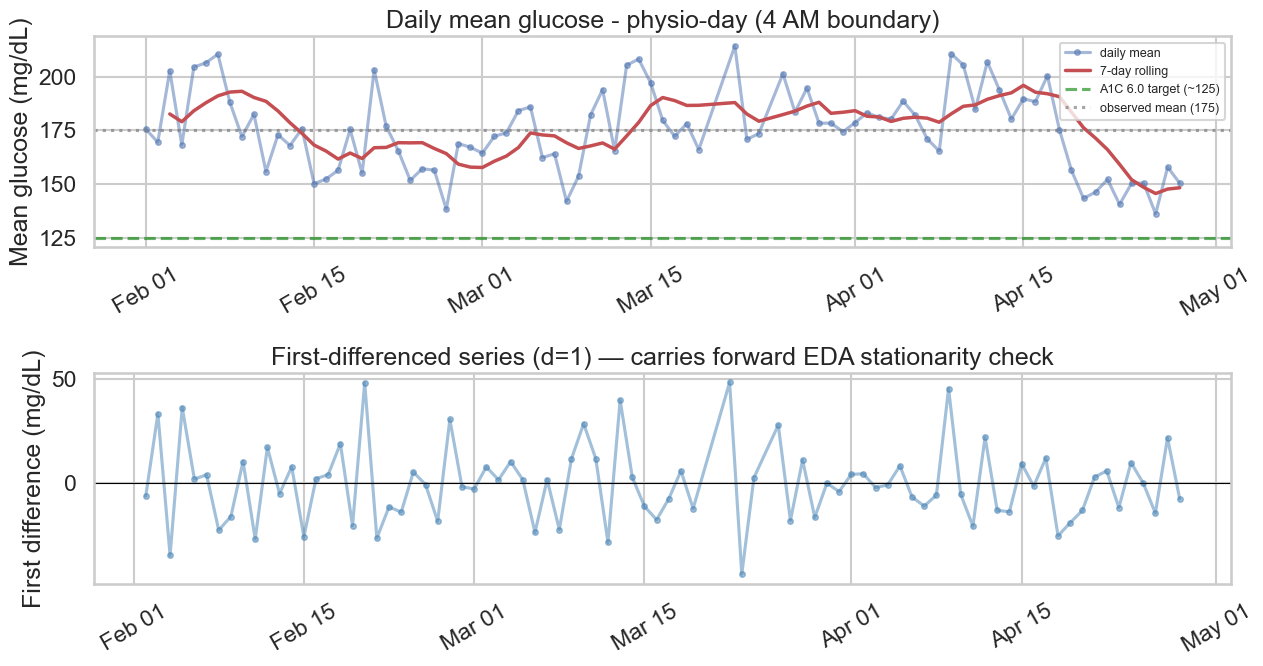

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

axes[0].plot(daily["date"], daily["mean_glucose"], "o-", alpha=0.5, markersize=4, label="daily mean")
axes[0].plot(daily["date"], daily["mean_glucose_7d_avg_descriptive"], "r-",
             linewidth=2.5, label="7-day rolling")
axes[0].axhline(125, color="green", linestyle="--", alpha=0.6, label="A1C 6.0 target (~125)")
axes[0].axhline(daily["mean_glucose"].mean(), color="gray", linestyle=":", alpha=0.7,
                label=f"observed mean ({daily['mean_glucose'].mean():.0f})")
axes[0].set_ylabel("Mean glucose (mg/dL)")
axes[0].set_title("Daily mean glucose - physio-day (4 AM boundary)")
axes[0].legend(fontsize=9, loc="upper right")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

diff1 = daily["mean_glucose"].diff().dropna()
axes[1].plot(daily["date"].iloc[1:], diff1, "o-", alpha=0.5, markersize=4, color="steelblue")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("First difference (mg/dL)")
axes[1].set_title("First-differenced series (d=1) — carries forward EDA stationarity check")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## 3. Train / test split and exogenous prep

Hold out the last 21 days (same as per-meal model). Exog regressors are contemporaneous: walk, carbs, and IF status for the same day as the target. For evaluation we use actual observed test-period values; for counterfactuals we set them to scenario values.

In [3]:
HOLDOUT_DAYS = 21
cutoff = daily["date"].max() - pd.Timedelta(days=HOLDOUT_DAYS)
train  = daily[daily["date"] <= cutoff].copy()
test   = daily[daily["date"]  > cutoff].copy()

print(f"Cutoff: {cutoff.date()}")
print(f"Train: {len(train)} days  ({train['date'].min().date()} -> {train['date'].max().date()})")
print(f"Test:  {len(test)} days  ({test['date'].min().date()}  -> {test['date'].max().date()})")

y_train = train.set_index("date")["mean_glucose"]
y_test  = test.set_index("date")["mean_glucose"]
X_train = train.set_index("date")[EXOG_COLS].astype(float)
X_test  = test.set_index("date")[EXOG_COLS].astype(float)

print("\nExog means  train vs test:")
for c in EXOG_COLS:
    print(f"  {c:20s}  train={X_train[c].mean():.1f}  test={X_test[c].mean():.1f}")

Cutoff: 2026-04-07
Train: 63 days  (2026-02-01 -> 2026-04-07)
Test:  21 days  (2026-04-08  -> 2026-04-28)

Exog means  train vs test:
  total_walk_min        train=16.2  test=18.2
  total_carbs           train=114.9  test=107.3
  is_if_day             train=0.2  test=0.2


## 4. Model selection via AIC grid

EDA (notebook 00) identified: ADF p=0.017 (borderline stationary), weekly seasonality at lag 7, PACF cut-off suggesting AR(1). Starting point is SARIMAX(1,1,1)(1,0,1,7). With only 63 training days, parsimony matters more than expressiveness.

In [4]:
CANDIDATES = [
    ((1, 1, 1), (1, 0, 1, 7), "SARIMAX(1,1,1)(1,0,1,7)  EDA starting point"),
    ((1, 0, 1), (1, 0, 1, 7), "SARIMAX(1,0,1)(1,0,1,7)  no differencing"),
    ((2, 1, 1), (1, 0, 1, 7), "SARIMAX(2,1,1)(1,0,1,7)  extra AR lag"),
    ((1, 1, 2), (1, 0, 1, 7), "SARIMAX(1,1,2)(1,0,1,7)  extra MA lag"),
    ((1, 1, 1), (0, 0, 1, 7), "SARIMAX(1,1,1)(0,0,1,7)  SMA only"),
    ((1, 1, 1), (0, 0, 0, 0), "SARIMAX(1,1,1)(0,0,0,0)  no seasonality"),
]

results_grid = []
for order, seasonal_order, label in CANDIDATES:
    try:
        m = SARIMAX(y_train, exog=X_train, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
        r = m.fit(disp=False)
        results_grid.append({"label": label, "order": order,
                              "seasonal_order": seasonal_order,
                              "aic": r.aic, "bic": r.bic, "result": r})
        print(f"  AIC={r.aic:8.2f}  BIC={r.bic:8.2f}  {label}")
    except Exception as e:
        print(f"  FAILED: {label} -- {e}")

best_row = min(results_grid, key=lambda x: x["aic"])
best     = best_row["result"]
print(f"\nBest model (lowest AIC): {best_row['label']}")

  AIC=  455.03  BIC=  470.79  SARIMAX(1,1,1)(1,0,1,7)  EDA starting point


  AIC=  533.37  BIC=  549.29  SARIMAX(1,0,1)(1,0,1,7)  no differencing


  AIC=  456.62  BIC=  474.36  SARIMAX(2,1,1)(1,0,1,7)  extra AR lag


  AIC=  446.82  BIC=  464.39  SARIMAX(1,1,2)(1,0,1,7)  extra MA lag
  AIC=  453.54  BIC=  467.33  SARIMAX(1,1,1)(0,0,1,7)  SMA only


  AIC=  514.56  BIC=  527.13  SARIMAX(1,1,1)(0,0,0,0)  no seasonality

Best model (lowest AIC): SARIMAX(1,1,2)(1,0,1,7)  extra MA lag


## 5. Best model summary and diagnostics

In [5]:
print(best.summary())

                                      SARIMAX Results                                      
Dep. Variable:                        mean_glucose   No. Observations:                   63
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 7)   Log Likelihood                -214.412
Date:                             Sun, 17 May 2026   AIC                            446.824
Time:                                     12:26:20   BIC                            464.385
Sample:                                          0   HQIC                           453.556
                                              - 63                                         
Covariance Type:                               opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
total_walk_min    -0.0301      0.146     -0.206      0.837      -0.316       0.256
total_carbs    

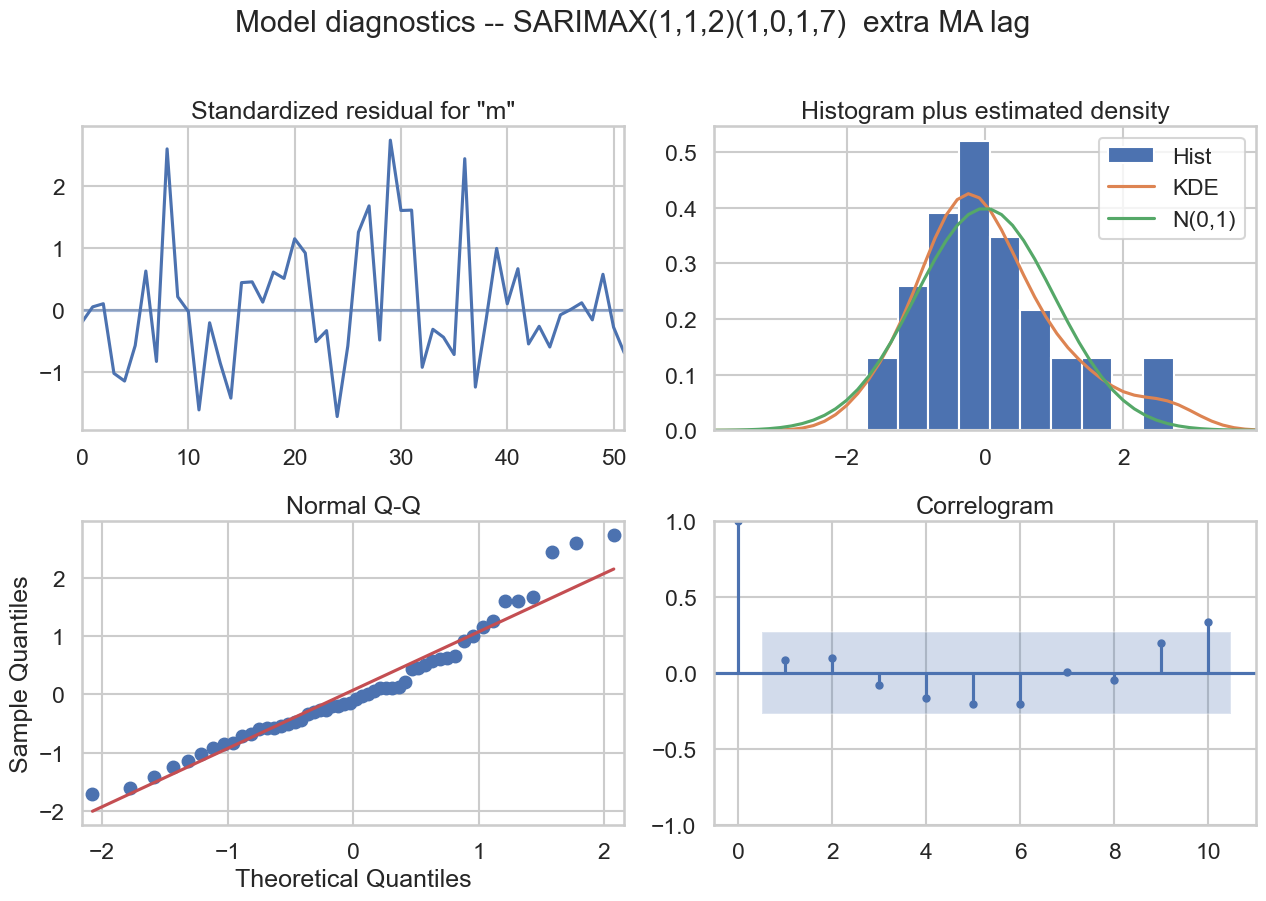

In [6]:
best.plot_diagnostics(figsize=(13, 9))
plt.suptitle(f"Model diagnostics -- {best_row['label']}", y=1.01)
plt.tight_layout()
plt.show()

In [7]:
resid = best.resid.dropna()
lb = acorr_ljungbox(resid, lags=[7, 14, 21], return_df=True)
print("Ljung-Box test on residuals (H0: no autocorrelation):")
print(lb.round(4))
print(f"\nResidual mean: {resid.mean():.3f}  (should be ~0)")
print(f"Residual std:  {resid.std():.2f} mg/dL")
_, p_norm = stats.shapiro(resid)
print(f"Shapiro-Wilk p: {p_norm:.4f}  ({'normal' if p_norm > 0.05 else 'non-normal'} residuals)")

Ljung-Box test on residuals (H0: no autocorrelation):
    lb_stat  lb_pvalue
7    7.2530     0.4030
14   9.1345     0.8223
21  12.5006     0.9251

Residual mean: 4.593  (should be ~0)
Residual std:  28.42 mg/dL
Shapiro-Wilk p: 0.0000  (non-normal residuals)


## 6. Test-set forecast

Two views of forecast quality:
1. **Multi-step** (`dynamic=True`): forecast all 21 test days from the training cutoff using only predicted lags — the real planning scenario.
2. **One-step-ahead** (`dynamic=False`): at each test day use the actual previous glucose as the AR input — upper bound on achievable accuracy.

In [8]:
# Multi-step: forecast all test days from end of training
fc_multi = best.get_forecast(steps=len(y_test), exog=X_test)
fc_mean  = fc_multi.predicted_mean
fc_ci    = fc_multi.conf_int()

# One-step-ahead: apply fitted params to the full series, using actual lags at each step
full_model = SARIMAX(
    pd.concat([y_train, y_test]),
    exog=pd.concat([X_train, X_test]),
    order=best_row["order"],
    seasonal_order=best_row["seasonal_order"],
    enforce_stationarity=False,
    enforce_invertibility=False,
)
full_filtered = full_model.filter(best.params)
pred_1step = full_filtered.fittedvalues.iloc[len(y_train):]

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.array(y_true) - np.array(y_pred))))

def score(y_true, y_pred, label):
    r = rmse(y_true, y_pred)
    m = mae(y_true, y_pred)
    print(f"  {label:22s}  RMSE={r:.2f}  MAE={m:.2f} mg/dL")
    return r, m

print("Test-set forecast accuracy:")
rmse_multi, mae_multi = score(y_test, fc_mean, "multi-step")
rmse_1step, mae_1step = score(y_test, pred_1step, "1-step-ahead")
naive_rmse = rmse(y_test, [y_train.mean()] * len(y_test))
print(f"  {'naive (train mean)':22s}  RMSE={naive_rmse:.2f}")

Test-set forecast accuracy:
  multi-step              RMSE=26.16  MAE=23.14 mg/dL
  1-step-ahead            RMSE=19.99  MAE=17.19 mg/dL
  naive (train mean)      RMSE=24.58


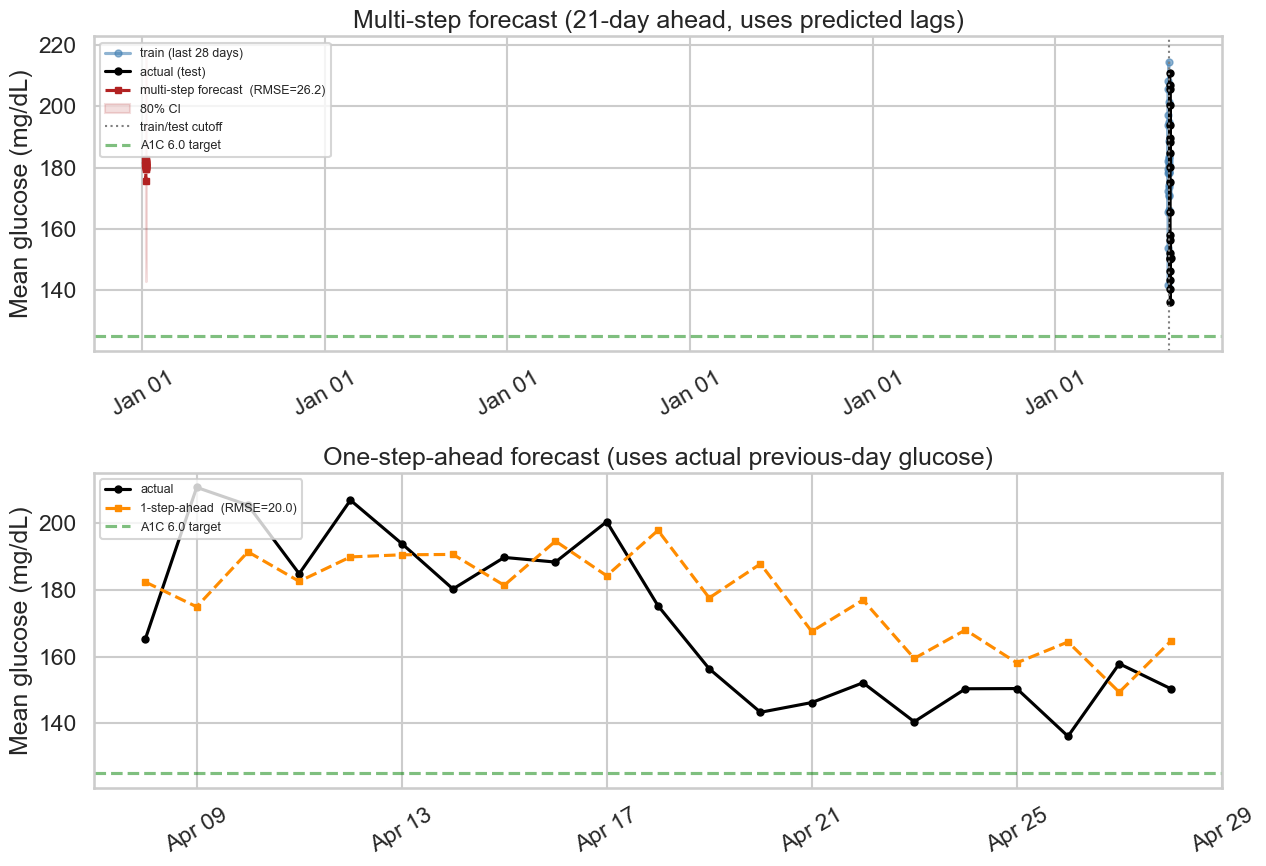

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=False)

# Multi-step panel
axes[0].plot(y_train.index[-28:], y_train.iloc[-28:], "o-", color="steelblue",
             alpha=0.6, markersize=5, label="train (last 28 days)")
axes[0].plot(y_test.index, y_test.values, "o-", color="black",
             markersize=5, label="actual (test)")
axes[0].plot(fc_mean.index, fc_mean.values, "s--", color="firebrick",
             markersize=5, label=f"multi-step forecast  (RMSE={rmse_multi:.1f})")
axes[0].fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                     color="firebrick", alpha=0.15, label="80% CI")
axes[0].axvline(cutoff, color="gray", linestyle=":", linewidth=1.5, label="train/test cutoff")
axes[0].axhline(125, color="green", linestyle="--", alpha=0.5, label="A1C 6.0 target")
axes[0].set_ylabel("Mean glucose (mg/dL)")
axes[0].set_title("Multi-step forecast (21-day ahead, uses predicted lags)")
axes[0].legend(fontsize=9, loc="upper left")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# One-step-ahead panel
axes[1].plot(y_test.index, y_test.values, "o-", color="black",
             markersize=5, label="actual")
axes[1].plot(pred_1step.index, pred_1step.values, "s--", color="darkorange",
             markersize=5, label=f"1-step-ahead  (RMSE={rmse_1step:.1f})")
axes[1].axhline(125, color="green", linestyle="--", alpha=0.5, label="A1C 6.0 target")
axes[1].set_ylabel("Mean glucose (mg/dL)")
axes[1].set_title("One-step-ahead forecast (uses actual previous-day glucose)")
axes[1].legend(fontsize=9, loc="upper left")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## 7. Exogenous coefficient interpretation

Coefficients are in original units (mg/dL per unit of regressor), after controlling for the autoregressive structure. They capture the same-day association.

**Caveat:** Walk and IF days still carry selection-bias confounding (same issue as in the per-meal model). Treat direction as reliable; magnitude as an upper bound on the causal effect.

Exogenous coefficients (mg/dL per unit):
                 coef     se   pval sig   ci_lo   ci_hi
total_walk_min -0.030  0.146  0.837  ns  -0.316   0.256
total_carbs    -0.022  0.043  0.607  ns  -0.107   0.062
is_if_day       0.631  6.704  0.925  ns -12.509  13.772

Practical effect sizes at typical doses:
  30-min walk:  -0.90 mg/dL per day
  -50g carbs:   +1.11 mg/dL per day
  1 IF day:     +0.63 mg/dL


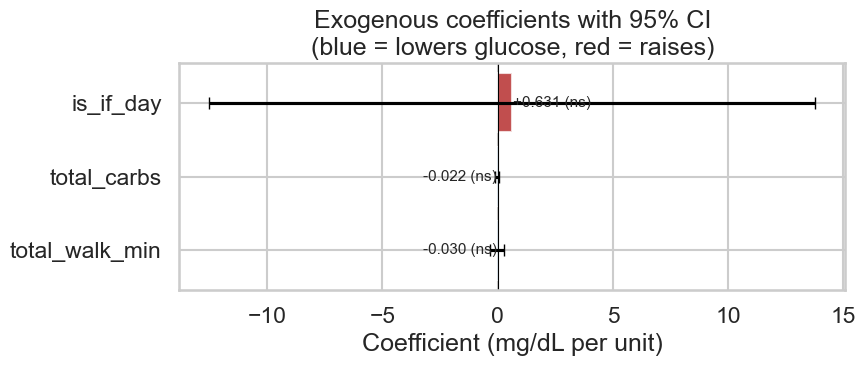

In [10]:
params = best.params
bse    = best.bse
pvals  = best.pvalues

exog_coef = pd.DataFrame({
    "coef": [params[c] for c in EXOG_COLS],
    "se":   [bse[c]    for c in EXOG_COLS],
    "pval": [pvals[c]  for c in EXOG_COLS],
}, index=EXOG_COLS)
exog_coef["ci_lo"] = exog_coef["coef"] - 1.96 * exog_coef["se"]
exog_coef["ci_hi"] = exog_coef["coef"] + 1.96 * exog_coef["se"]
exog_coef["sig"]   = exog_coef["pval"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns")))

print("Exogenous coefficients (mg/dL per unit):")
print(exog_coef[["coef", "se", "pval", "sig", "ci_lo", "ci_hi"]].round(3).to_string())

print("\nPractical effect sizes at typical doses:")
print(f"  30-min walk:  {30 * exog_coef.loc['total_walk_min', 'coef']:+.2f} mg/dL per day")
print(f"  -50g carbs:   {-50 * exog_coef.loc['total_carbs', 'coef']:+.2f} mg/dL per day")
print(f"  1 IF day:     {exog_coef.loc['is_if_day', 'coef']:+.2f} mg/dL")

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["steelblue" if c < 0 else "firebrick" for c in exog_coef["coef"]]
ax.barh(exog_coef.index, exog_coef["coef"], color=colors, alpha=0.8)
ax.errorbar(exog_coef["coef"], exog_coef.index,
            xerr=1.96 * exog_coef["se"], fmt="none", color="black", capsize=4)
ax.axvline(0, color="black", linewidth=0.8)
for i, (idx, row) in enumerate(exog_coef.iterrows()):
    offset = 0.02 if row["coef"] >= 0 else -0.02
    ha = "left" if row["coef"] >= 0 else "right"
    ax.text(row["coef"] + offset, i,
            f"{row['coef']:+.3f} ({row['sig']})", va="center", ha=ha, fontsize=11)
ax.set_xlabel("Coefficient (mg/dL per unit)")
ax.set_title("Exogenous coefficients with 95% CI\n(blue = lowers glucose, red = raises)")
plt.tight_layout()
plt.show()

## 8. Counterfactual scenarios — Goal 4

Project 30 days forward under three behavior scenarios. The ARMA component is initialized from the last observed state; exog values are set to scenario targets and held constant.

| Scenario | Walk (min/day) | Carbs (g/day) | IF days/week |
|---|---|---|---|
| A — Status quo | observed mean | observed mean | observed rate |
| B — Modest | 30 | −30 g vs baseline | 3 |
| C — Aggressive | 45 | −60 g vs baseline | 5 |

In [11]:
HORIZON = 30

base_walk  = daily["total_walk_min"].mean()
base_carbs = daily["total_carbs"].mean()
base_if    = daily["is_if_day"].mean()

scenarios = {
    "A - Status quo":
        [base_walk, base_carbs, base_if],
    "B - Modest (+30 walk, -30g carbs, 3x IF/wk)":
        [30.0, base_carbs - 30, 3 / 7],
    "C - Aggressive (+45 walk, -60g carbs, 5x IF/wk)":
        [45.0, base_carbs - 60, 5 / 7],
}

print(f"Baseline  walk={base_walk:.1f} min  carbs={base_carbs:.1f} g  IF rate={base_if:.2f}\n")

fc_dates = pd.date_range(
    start=daily["date"].max() + pd.Timedelta(days=1), periods=HORIZON, freq="D")
scenario_forecasts = {}

for name, (walk, carbs, if_rate) in scenarios.items():
    X_fc = pd.DataFrame({
        "total_walk_min": [walk]    * HORIZON,
        "total_carbs":    [carbs]   * HORIZON,
        "is_if_day":      [if_rate] * HORIZON,
    }, index=fc_dates)
    fc = best.get_forecast(steps=HORIZON, exog=X_fc)
    scenario_forecasts[name] = {"mean": fc.predicted_mean, "ci": fc.conf_int()}

    m30 = fc.predicted_mean.mean()
    gmi = 3.31 + 0.02392 * m30
    print(f"{name}")
    print(f"  30-day mean glucose: {m30:.1f}  implied GMI: {gmi:.2f}\n")

Baseline  walk=16.7 min  carbs=113.0 g  IF rate=0.17

A - Status quo
  30-day mean glucose: 180.6  implied GMI: 7.63

B - Modest (+30 walk, -30g carbs, 3x IF/wk)
  30-day mean glucose: 181.0  implied GMI: 7.64

C - Aggressive (+45 walk, -60g carbs, 5x IF/wk)
  30-day mean glucose: 181.4  implied GMI: 7.65



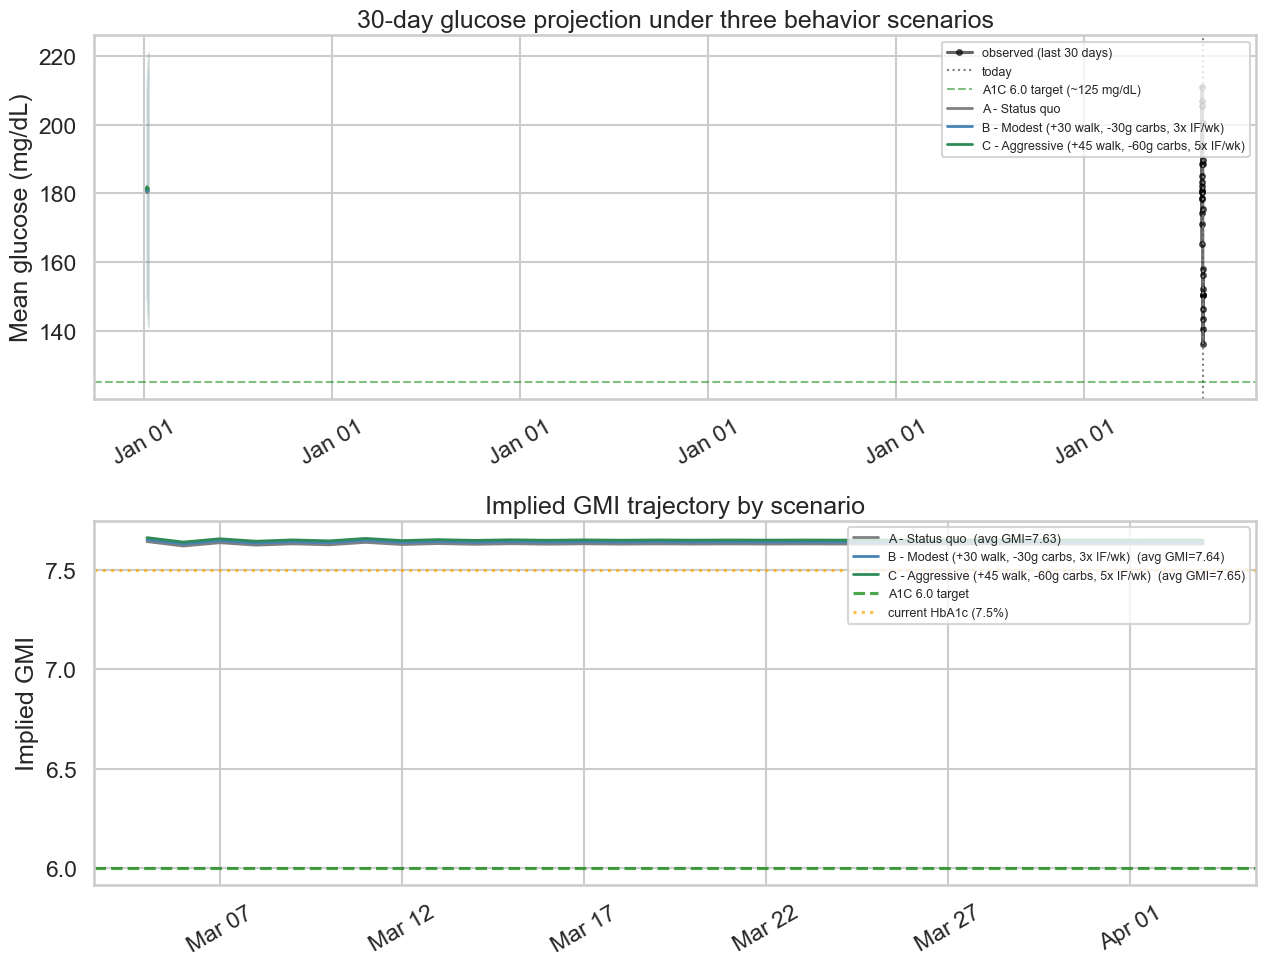

In [12]:
colors_sc = {
    "A - Status quo": "gray",
    "B - Modest (+30 walk, -30g carbs, 3x IF/wk)": "steelblue",
    "C - Aggressive (+45 walk, -60g carbs, 5x IF/wk)": "seagreen",
}

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

history_tail = daily.set_index("date")["mean_glucose"].iloc[-30:]
axes[0].plot(history_tail.index, history_tail.values, "o-", color="black",
             alpha=0.6, markersize=4, label="observed (last 30 days)")
axes[0].axvline(daily["date"].max(), color="gray", linestyle=":", linewidth=1.5, label="today")
axes[0].axhline(125, color="green", linestyle="--", alpha=0.5, linewidth=1.5,
                label="A1C 6.0 target (~125 mg/dL)")

for name, d in scenario_forecasts.items():
    col = colors_sc[name]
    axes[0].plot(d["mean"].index, d["mean"].values, "-", color=col, linewidth=2, label=name)
    axes[0].fill_between(d["ci"].index, d["ci"].iloc[:, 0], d["ci"].iloc[:, 1],
                         color=col, alpha=0.08)

axes[0].set_ylabel("Mean glucose (mg/dL)")
axes[0].set_title("30-day glucose projection under three behavior scenarios")
axes[0].legend(fontsize=9, loc="upper right")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

for name, d in scenario_forecasts.items():
    col     = colors_sc[name]
    gmi_tr  = 3.31 + 0.02392 * d["mean"]
    axes[1].plot(d["mean"].index, gmi_tr.values, "-", color=col, linewidth=2,
                 label=f"{name}  (avg GMI={gmi_tr.mean():.2f})")

axes[1].axhline(6.0, color="green", linestyle="--", alpha=0.7, label="A1C 6.0 target")
axes[1].axhline(7.5, color="orange", linestyle=":", alpha=0.7, label="current HbA1c (7.5%)")
axes[1].set_ylabel("Implied GMI")
axes[1].set_title("Implied GMI trajectory by scenario")
axes[1].legend(fontsize=9, loc="upper right")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

In [13]:
print("=" * 65)
print(f"{'Scenario':42s}  {'Mean Gluc':>10}  {'GMI':>6}  {'Gap to 6.0':>10}")
print("-" * 65)
for name, d in scenario_forecasts.items():
    m   = d["mean"].mean()
    gmi = 3.31 + 0.02392 * m
    print(f"{name[:42]:42s}  {m:10.1f}  {gmi:6.2f}  {gmi - 6.0:+10.2f}")
print("=" * 65)
obs_gmi = 3.31 + 0.02392 * daily["mean_glucose"].mean()
print(f"\nObserved:  mean={daily['mean_glucose'].mean():.1f}  GMI={obs_gmi:.2f}")
print(f"Target:    mean=125.0  GMI=6.00")

Scenario                                     Mean Gluc     GMI  Gap to 6.0
-----------------------------------------------------------------
A - Status quo                                   180.6    7.63       +1.63
B - Modest (+30 walk, -30g carbs, 3x IF/wk       181.0    7.64       +1.64
C - Aggressive (+45 walk, -60g carbs, 5x I       181.4    7.65       +1.65

Observed:  mean=175.0  GMI=7.50
Target:    mean=125.0  GMI=6.00


## 9. Caveats

- **Forecast uncertainty grows fast.** Multi-step CI widens rapidly beyond 7 days; treat the 30-day projection as a planning guide, not a point estimate.
- **Exog coefficients carry selection bias.** Walk and IF associations are confounded in the same way identified in the per-meal model. Direction is reliable; magnitude is an upper bound on causal effect.
- **Constant behavior assumption.** Counterfactuals hold behavior fixed for 30 days. Partial adherence yields a trajectory between Scenarios A and C proportionally.
- **doses_taken was all zeros** — medication dose-response is unidentifiable from this dataset. Revisit if adherence data becomes available.
- **n=63 training days.** The AIC-selected model may shift with more data, especially the seasonal terms which need many cycles to stabilize.

## 10. Save model artifacts

In [14]:
# Save fitted model using statsmodels' own pickle-based serialisation
best.save(os.path.join(MODEL_DIR, "sarimax_daily.pkl"))
# Save metadata separately so it can be read without statsmodels
with open(os.path.join(MODEL_DIR, "sarimax_daily_meta.pkl"), "wb") as f:
    pickle.dump({
        "order":          best_row["order"],
        "seasonal_order": best_row["seasonal_order"],
        "label":          best_row["label"],
        "exog_cols":      EXOG_COLS,
        "cutoff":         cutoff.isoformat(),
    }, f)
print("Saved sarimax_daily.pkl + sarimax_daily_meta.pkl")

sarimax_metrics = {
    "best_model":          best_row["label"],
    "aic":                 best_row["aic"],
    "bic":                 best_row["bic"],
    "test_rmse_multistep": float(rmse_multi),
    "test_mae_multistep":  float(mae_multi),
    "test_rmse_1step":     float(rmse_1step),
    "test_mae_1step":      float(mae_1step),
    "exog_coefs":          exog_coef[["coef", "se", "pval"]].round(4).to_dict(),
    "scenario_30d_mean_glucose": {
        name: float(d["mean"].mean()) for name, d in scenario_forecasts.items()
    },
    "scenario_30d_gmi": {
        name: round(3.31 + 0.02392 * float(d["mean"].mean()), 3)
        for name, d in scenario_forecasts.items()
    },
}
with open(os.path.join(MODEL_DIR, "sarimax_metrics.json"), "w") as f:
    json.dump(sarimax_metrics, f, indent=2, default=float)
print("Saved sarimax_metrics.json")
print(json.dumps(
    {k: v for k, v in sarimax_metrics.items() if k != "exog_coefs"},
    indent=2, default=float))

Saved sarimax_daily.pkl + sarimax_daily_meta.pkl
Saved sarimax_metrics.json
{
  "best_model": "SARIMAX(1,1,2)(1,0,1,7)  extra MA lag",
  "aic": 446.82384497019643,
  "bic": 464.3850384374293,
  "test_rmse_multistep": 26.162149371138028,
  "test_mae_multistep": 23.135664872236653,
  "test_rmse_1step": 19.993479766932158,
  "test_mae_1step": 17.19218893052768,
  "scenario_30d_mean_glucose": {
    "A - Status quo": 180.60335550023447,
    "B - Modest (+30 walk, -30g carbs, 3x IF/wk)": 181.0352257972652,
    "C - Aggressive (+45 walk, -60g carbs, 5x IF/wk)": 181.43203001848187
  },
  "scenario_30d_gmi": {
    "A - Status quo": 7.63,
    "B - Modest (+30 walk, -30g carbs, 3x IF/wk)": 7.64,
    "C - Aggressive (+45 walk, -60g carbs, 5x IF/wk)": 7.65
  }
}
